In [1]:
import numpy as np
import sys
sys.path.insert(0, '../src/')
from oz import PyOZ
import matplotlib.pyplot as plt
import torch

In [2]:
def ulj(r,params):
    [sigma,eps] = params
    return 4*eps*((sigma/r)**12-(sigma/r)**6)

In [3]:
sigma=1.0
eps=1.0

In [4]:
ljHNC = PyOZ(ulj,params=[sigma,eps],closure='HNC',device='cuda',dtype=torch.float32)
ljPY = PyOZ(ulj,params=[sigma,eps],closure='PY',device='cuda',dtype=torch.float32)

Defining the grid size

In [5]:
dr = 0.01

## Comparing with RDF from MD Data Verlet 1968

In [6]:
kT = 2.934
rhob = 0.45

r, h, c = ljHNC.solve(rho=rhob, kBT=kT, rmax = 10.0, dr = dr)
gHNC = h + 1.0

r, h, c = ljPY.solve(rho=rhob, kBT=kT, rmax = 10.0, dr = dr)
gPY = h + 1.0

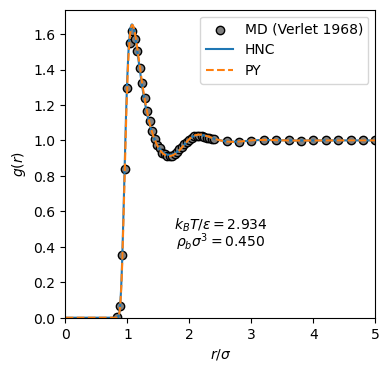

In [7]:
import pandas as pd
VerletMDdata = pd.read_excel('data/MCdata-radialdistribution-lennardjones-Verlet1968.xls',sheet_name=f'rhob={rhob:.3f}')

fig = plt.figure(figsize=(4,4))
plt.scatter(VerletMDdata['r'],VerletMDdata[f'KT={kT:.3f}'],marker='o',edgecolors='k',facecolors='grey',label='MD (Verlet 1968)')

plt.plot(r.cpu().numpy(),gHNC.cpu().numpy(),'-',color='C0',label='HNC')
plt.plot(r.cpu().numpy(),gPY.cpu().numpy(),'--',color='C1',label='PY')

plt.xlim(0.0,5.0)
plt.ylim(0,None)
plt.xlabel(r'$r/\sigma$')
plt.ylabel(r'$g(r)$')
plt.text(2.5,0.5,rf'$k_B T/\epsilon = {kT:.3f}$',ha='center')
plt.text(2.5,0.4,rf'$\rho_b \sigma^3 = {rhob:.3f}$',ha='center')
plt.legend(loc='upper right',ncol=1)

In [8]:
kT = 2.888
rhob = 0.850

r, h, c = ljHNC.solve(rho=rhob, kBT=kT, rmax = 10.0, dr=dr)
gHNC = h + 1.0

r, h, c = ljPY.solve(rho=rhob, kBT=kT, rmax = 10.0, dr=dr)
gPY = h + 1.0

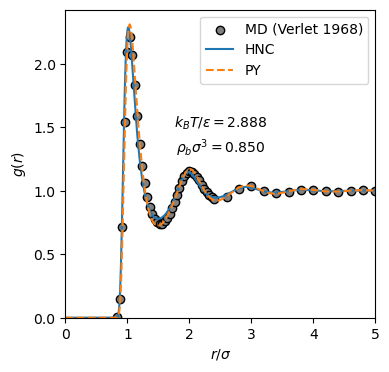

In [9]:
VerletMDdata = pd.read_excel('data/MCdata-radialdistribution-lennardjones-Verlet1968.xls',sheet_name=f'rhob={rhob:.3f}')

fig = plt.figure(figsize=(4,4))
plt.scatter(VerletMDdata['r'],VerletMDdata[f'KT={kT:.3f}'],marker='o',edgecolors='k',facecolors='grey',label='MD (Verlet 1968)')

plt.plot(r.cpu().numpy(),gHNC.cpu().numpy(),'-',color='C0',label='HNC')
plt.plot(r.cpu().numpy(),gPY.cpu().numpy(),'--',color='C1',label='PY')

plt.xlim(0.0,5.0)
plt.ylim(0,None)
plt.xlabel(r'$r/\sigma$')
plt.ylabel(r'$g(r)$')
plt.text(2.5,1.5,rf'$k_B T/\epsilon = {kT:.3f}$',ha='center')
plt.text(2.5,1.3,rf'$\rho_b \sigma^3 = {rhob:.3f}$',ha='center')
plt.legend(loc='upper right',ncol=1)

## Argon at triple point

In [10]:
kT = 0.71
rhob = 0.84

r, h, c = ljHNC.solve(rho=rhob, kBT=kT, rmax = 10.0, dr=dr)
gHNC = h + 1.0

r, h, c = ljPY.solve(rho=rhob, kBT=kT, rmax = 10.0, dr=dr)
gPY = h + 1.0

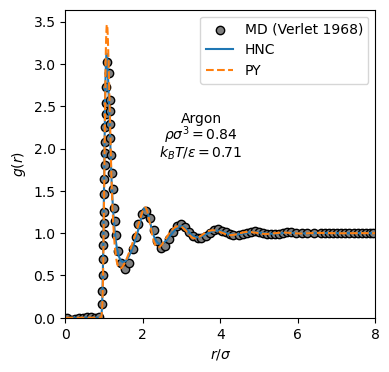

In [11]:
VerletMDdata = pd.read_excel('data/MCdata-radialdistribution-lennardjones-Verlet1968.xls',sheet_name=f'Argon')

fig = plt.figure(figsize=(4,4))
plt.scatter(VerletMDdata['r']/3.405,VerletMDdata['KT=0.71-rhob=0.84'],marker='o',edgecolors='k',facecolors='grey',label='MD (Verlet 1968)')

plt.plot(r.cpu().numpy(),gHNC.cpu().numpy(),'-',color='C0',label='HNC')
plt.plot(r.cpu().numpy(),gPY.cpu().numpy(),'--',color='C1',label='PY')

plt.xlim(0,8)
plt.ylim(0,None)
plt.legend(loc='best')
plt.xlabel(r'$r/\sigma$')
plt.ylabel(r'$g(r)$')
plt.text(3.5,2.3,r'Argon',ha='center')
plt.text(3.5,2.1,r'$\rho \sigma^3 = 0.84$',ha='center')
plt.text(3.5,1.9,r'$k_B T/\epsilon = 0.71$',ha='center')
plt.savefig('radialdistributionfunction-argon-lennardjones.png',dpi=200)